# Snapshot eval violins — across seeds

Compares **per-episode eval metrics** across differently *seeded* eval reruns of a
single snapshot's single evaluation kind. This is the companion to
`snapshot_eval_violins.ipynb` (which compares algorithms/snapshots side by side); here
the x-axis is `--seed` fan-outs evaluating the **same** trained policy, produced via:

```bash
python -m tools.snapshot.submit_snapshot --snapshot snapshots/<existing>/ --kind eval --seed 43 -- --episodes 10
```

Set `SNAPSHOT_PATH` and `EVAL_KIND` in the next cell. Within that one snapshot, every
`runs/` directory matching the requested kind is discovered — the run without a
`_seed{N}` suffix is the default run (`trial.seed`, unchanged), later `--seed N` runs are
named `<kind>_<timestamp>_seed{N}`:

| `EVAL_KIND` | Run directory pattern | Producer | Per-run CSV |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>[_seed{N}]/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>[_seed{N}]/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>[_seed{N}]/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/episodes.csv` |

For `eval-rbc`, also set `RBC_STRATEGY` — a run directory can hold several strategies,
but a single violin figure only compares one strategy across seeds.

The **actual** seed a run used is read from that run's own metadata (the Ray/SB3 eval
sidecar JSON's `"seed"` field, or the rule-based `args.json`'s `"resolved_seed"`) —
never assumed from the directory name — because a run without a `_seed{N}` suffix still
ran with whatever `trial.seed` the snapshot's frozen trial YAML declares.

**Main input:** set `SNAPSHOT_PATH`, `EVAL_KIND` (and `RBC_STRATEGY` if applicable) in
the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# Path to the single snapshot to analyse (absolute, or relative to the repo root).
SNAPSHOT_PATH = "snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base"

# Which evaluation kind's runs (and their _seed{N} fan-outs) to pick up.
EVAL_KIND = "eval-rbc"  # one of "eval-ray", "eval-sb", "eval-rbc"

# Only used when EVAL_KIND == "eval-rbc": which rule-based strategy to compare across
# seeds (a run directory can hold several strategies). Leave None if only one strategy
# was evaluated; otherwise set e.g. "do_nothing".
# ['deficit_discharge', 'do_nothing', 'price_median', 'price_median_autarky', 
# 'price_median_scaled_0.25', 'price_median_scaled_0.5', 'price_median_scaled_0.75', 
# 'pv_surplus_charge', 'self_coverage']
RBC_STRATEGY = 'price_median_scaled_0.25'


In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")
if EVAL_KIND not in EVAL_KINDS:
    raise ValueError(f"EVAL_KIND must be one of {EVAL_KINDS}, got {EVAL_KIND!r}")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from plotting/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

snapshot_dir = Path(SNAPSHOT_PATH)
snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
if not snapshot_dir.is_dir():
    raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")


# Maps a runs/eval_* directory to its EVAL_KIND bucket — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind (eval -> eval-ray,
# eval-sb -> eval-sb, eval-rbc -> eval-rbc).
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


_SEED_SUFFIX_REGEX = re.compile(r"_seed(-?\d+)$")


# Parses an explicit --seed N fan-out from the run id; None for the un-suffixed default run.
def _seed_suffix(run_dir: Path) -> int | None:
    match = _SEED_SUFFIX_REGEX.search(run_dir.name)
    return int(match.group(1)) if match else None


run_dirs = [
    run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
    if _run_dir_eval_kind(run_dir) == EVAL_KIND
]
if not run_dirs:
    raise FileNotFoundError(f"No '{EVAL_KIND}' run directories found under {snapshot_dir / 'runs'}")

print(f"Snapshot : {snapshot_dir}")
print(f"Eval kind: {EVAL_KIND}")
for run_dir in run_dirs:
    suffix = _seed_suffix(run_dir)
    tag = f"--seed {suffix}" if suffix is not None else "default seed"
    print(f"  {run_dir.name}  [{tag}]")


Snapshot : /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base
Eval kind: eval-rbc
  eval_rbc_20260705_234932  [default seed]
  eval_rbc_20260706_133838_seed43  [--seed 43]
  eval_rbc_20260706_133839_seed44  [--seed 44]
  eval_rbc_20260706_133840_seed45  [--seed 45]
  eval_rbc_20260706_133841_seed46  [--seed 46]
  eval_rbc_20260706_133842_seed70  [--seed 70]
  eval_rbc_20260706_133843_seed71  [--seed 71]
  eval_rbc_20260706_133844_seed140  [--seed 140]
  eval_rbc_20260706_133845_seed141  [--seed 141]


## Discover the eval CSVs

One record per run directory (per strategy, for `eval-rbc`). The seed used for the
x-axis is read from each run's own metadata — never parsed from the directory name —
so the un-suffixed default run still gets its correct (`trial.seed`) label.

In [3]:
# Ray/SB3 eval CSV's sidecar JSON (same stem) carries the actual trial.seed this run used.
def _sidecar_seed_and_algorithm(csv_path: Path) -> tuple[int | None, str | None]:
    sidecar = csv_path.with_suffix(".json")
    if not sidecar.is_file():
        return None, None
    try:
        payload = json.loads(sidecar.read_text())
    except (json.JSONDecodeError, OSError):
        return None, None
    return payload.get("seed"), payload.get("algorithm")


# Rule-based episodes.csv's sibling args.json (one level above the per-strategy dir) records resolved_seed.
def _rbc_resolved_seed(csv_path: Path) -> int | None:
    args_path = csv_path.parent.parent / "args.json"
    if not args_path.is_file():
        return None
    try:
        payload = json.loads(args_path.read_text())
    except (json.JSONDecodeError, OSError):
        return None
    return payload.get("resolved_seed")


def _discover_records_for_run(run_dir: Path) -> list[dict]:
    records = []
    if EVAL_KIND == "eval-rbc":
        for csv_path in sorted(run_dir.glob("eval_results/*_rule_based/*/episodes.csv")):
            if RBC_STRATEGY is not None and csv_path.parent.name != RBC_STRATEGY:
                continue
            seed = _rbc_resolved_seed(csv_path)
            records.append({"run": run_dir.name, "strategy": csv_path.parent.name, "seed": seed, "csv": csv_path})
    else:
        for csv_path in sorted(run_dir.glob("eval_results/*_eval/eval_*.csv")):
            seed, algorithm = _sidecar_seed_and_algorithm(csv_path)
            records.append({"run": run_dir.name, "algorithm": algorithm, "seed": seed, "csv": csv_path})
    return records


eval_records: list[dict] = []
for run_dir in run_dirs:
    run_records = _discover_records_for_run(run_dir)
    if not run_records:
        print(f"WARNING: no eval CSVs found under {run_dir}")
        continue
    eval_records.extend(run_records)

if not eval_records:
    raise FileNotFoundError(f"No eval CSVs discovered for any '{EVAL_KIND}' run under {snapshot_dir}")

if EVAL_KIND == "eval-rbc":
    strategies = sorted({record["strategy"] for record in eval_records})
    if RBC_STRATEGY is None and len(strategies) > 1:
        raise ValueError(
            f"Multiple rule-based strategies found ({strategies}) — set RBC_STRATEGY to one of them "
            "so the violin axis stays a single-strategy seed comparison."
        )

_missing_seed = [record for record in eval_records if record["seed"] is None]
for record in _missing_seed:
    print(f"WARNING: could not resolve the seed for {record['csv']} — dropped")
eval_records = [record for record in eval_records if record["seed"] is not None]

# One violin per seed; sort ascending so the x-axis reads left-to-right.
eval_records.sort(key=lambda record: record["seed"])

_seed_counts = pd.Series([record["seed"] for record in eval_records]).value_counts()
_duplicate_seeds = _seed_counts[_seed_counts > 1]
if not _duplicate_seeds.empty:
    print(
        f"WARNING: multiple runs share the same seed — {dict(_duplicate_seeds)}; "
        "each is still plotted as its own violin (labelled by run id)."
    )


def _label_for(record: dict) -> str:
    return f"seed {record['seed']}" if _seed_counts[record["seed"]] == 1 else f"seed {record['seed']} ({record['run']})"


for record in eval_records:
    record["label"] = _label_for(record)


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


pd.DataFrame(
    {
        "label": record["label"],
        "seed": record["seed"],
        "run": record["run"],
        **({"strategy": record["strategy"]} if EVAL_KIND == "eval-rbc" else {"algorithm": record.get("algorithm")}),
        "csv": _display_path(record["csv"]),
    }
    for record in eval_records
)


,label,seed,run,strategy,csv
0,seed 42,42,eval_rbc_20260705_234932,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
1,seed 43,43,eval_rbc_20260706_133838_seed43,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
2,seed 44,44,eval_rbc_20260706_133839_seed44,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
3,seed 45,45,eval_rbc_20260706_133840_seed45,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
4,seed 46,46,eval_rbc_20260706_133841_seed46,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
5,seed 70,70,eval_rbc_20260706_133842_seed70,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
6,seed 71,71,eval_rbc_20260706_133843_seed71,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
7,seed 140,140,eval_rbc_20260706_133844_seed140,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...
8,seed 141,141,eval_rbc_20260706_133845_seed141,price_median_scaled_0.25,snapshots/20260705_234931_sta_lin_battery_only...


## Load per-episode metrics

All CSVs are concatenated into one long-format frame, one row per episode, tagged with
the run's seed.

In [4]:
METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: '{record['label']}' has no {missing} column(s) — skipped in those figures")
    frame = csv_frame[[metric for metric in METRICS if metric in csv_frame.columns]].copy()
    frame["label"] = record["label"]
    frame["seed"] = record["seed"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
label_order = [record["label"] for record in eval_records]

episodes.groupby(["label", "seed"], sort=False).agg(
    episodes=("total_reward", "size"),
    mean_total_reward=("total_reward", "mean"),
    mean_cum_E_kWh=("cum_E_kWh", "mean"),
    mean_cum_price_EUR=("cum_price_EUR", "mean"),
)


,,episodes,mean_total_reward,mean_cum_E_kWh,mean_cum_price_EUR
label,seed,,,,
seed 42,42,10,9.735845,42.604213,-2.698555
seed 43,43,10,9.918905,44.112668,-2.692047
seed 44,44,10,9.202446,43.865742,-3.006988
seed 45,45,10,9.374885,42.690142,-3.193831
seed 46,46,10,9.090223,41.950212,-2.953566
seed 70,70,10,10.435013,42.079745,-2.974368
seed 71,71,10,10.852509,44.034734,-3.397704
seed 140,140,10,9.254015,41.463962,-2.739575
seed 141,141,10,7.744611,41.522957,-2.418653


## Violin plots

One violin per seed; individual episodes overlaid as dots. Each violin carries two stat
markers: **mean** (red dot) and **median** (narrow dashed line). Each figure is saved
into the snapshot's `stat/` directory as `violin_<metric>_seeds_<algorithm-or-strategy>.pdf`
— the `_seeds_` infix keeps these exports distinct from `snapshot_eval_violins.ipynb`'s
`violin_<metric>.pdf` outputs for the same snapshot.

`violin_for_metric(metric, title_override=...)` replaces the default
`<metric> — <algorithm/strategy> (<kind>) — <snapshot>` figure title with the given string.

In [5]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

VIOLIN_COLOR = "#89f0cc" if EVAL_KIND == "eval-rbc" else "#75aef4"  # RBC green vs. RL blue, matching snapshot_eval_violins.ipynb
METRIC_LABELS = {
    "total_reward": "Total reward per episode",
    "cum_E_kWh": "Cumulative energy consumption [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

if EVAL_KIND == "eval-rbc":
    _series_name = RBC_STRATEGY or eval_records[0]["strategy"]
else:
    _algorithms = {record.get("algorithm") for record in eval_records if record.get("algorithm")}
    _series_name = _algorithms.pop() if len(_algorithms) == 1 else "/".join(sorted(_algorithms)) or "unknown"

_kind_tag = re.sub(r"\W+", "_", f"{_series_name}_{EVAL_KIND}").strip("_").lower()
FIGURE_TITLE_SUFFIX = f"{_series_name} ({EVAL_KIND})" #  — {snapshot_dir.name}


# Overlays the mean (red dot) and median (narrow dashed line) of each violin.
def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    stats = data.groupby("label")[metric].agg(["mean", "median"])
    for x_position, label in enumerate(label_order):
        if label not in stats.index:
            continue
        row = stats.loc[label]
        ax.hlines(
            row["median"], x_position - 0.23, x_position + 0.23,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


# Draws one violin per seed for `metric` and exports the figure as a PDF into the
# snapshot's stat/. `title_override` replaces the default figure title when given.
def violin_for_metric(metric: str, title_override: str | None = None) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(6.0, 1.15 * len(label_order))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="label",
        y=metric,
        order=label_order,
        color=VIOLIN_COLOR,
        density_norm="area",
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="label", y=metric, order=label_order,
        color="0.1", size=3, alpha=0.6, jitter=0.08, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(title_override if title_override else f"{metric} — {FIGURE_TITLE_SUFFIX}", pad=12)
    ax.grid(axis="x", visible=False)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
            markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    ax.legend(
        handles=stat_handles,
        labels=[handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    stat_dir = snapshot_dir / "stat"
    stat_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = stat_dir / f"violin_{metric}_seeds_{_kind_tag}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    plt.show()


saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_total_reward_seeds_price_median_scaled_0_25_eval_rbc.pdf


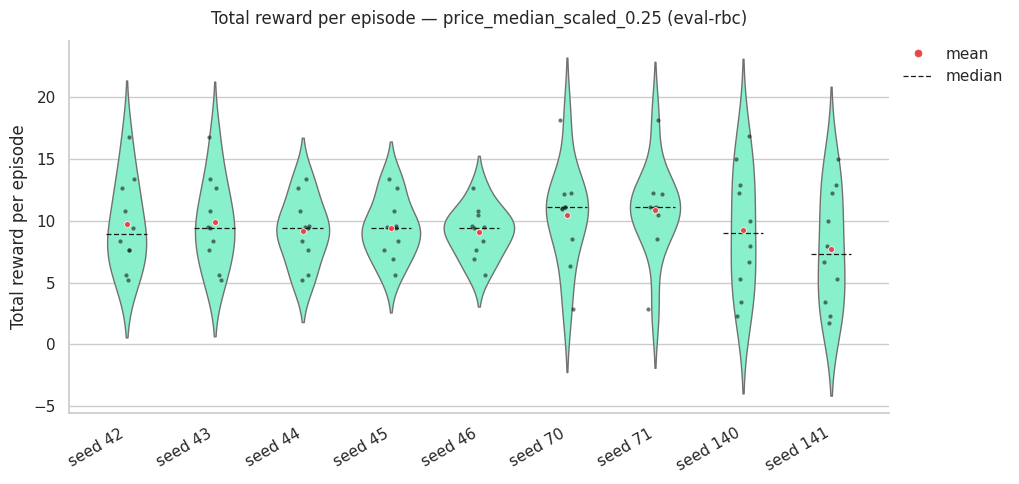

In [6]:
violin_for_metric("total_reward",
    title_override=f"Total reward per episode — {FIGURE_TITLE_SUFFIX}")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_E_kWh_seeds_price_median_scaled_0_25_eval_rbc.pdf


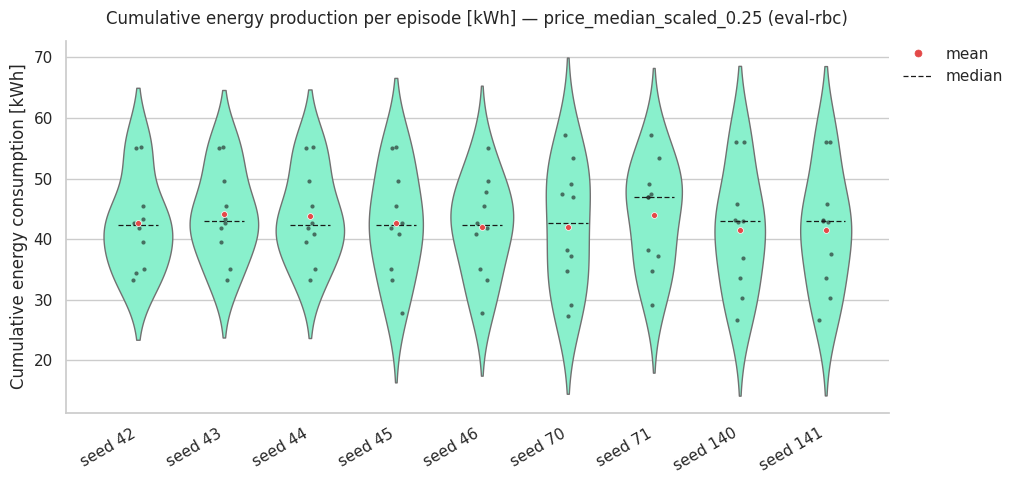

In [7]:
violin_for_metric("cum_E_kWh",
    title_override=f"Cumulative energy production per episode [kWh] — {FIGURE_TITLE_SUFFIX}")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260705_234931_sta_lin_battery_only_price_rbc_base/stat/violin_cum_price_EUR_seeds_price_median_scaled_0_25_eval_rbc.pdf


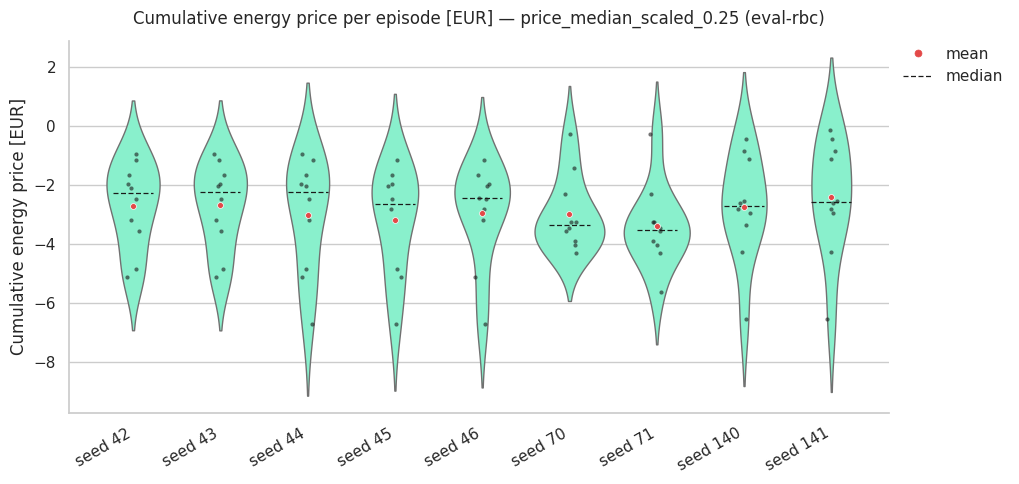

In [8]:
violin_for_metric("cum_price_EUR",
    title_override=f"Cumulative energy price per episode [EUR] — {FIGURE_TITLE_SUFFIX}")

## Variance across seeds

Quick summary of how much the trained policy's per-episode metrics vary across the
differently seeded (held-out) evaluation rounds: the mean of each metric is first taken
within each seed, then `mean` / `std` / `min` / `max` are taken across seeds — a small
`std` means the policy generalises consistently across the held-out data draws each
seed selects.

In [9]:
seed_means = episodes.groupby("seed")[[metric for metric in METRICS if metric in episodes.columns]].mean()
seed_means.agg(["mean", "std", "min", "max"])


,total_reward,cum_E_kWh,cum_price_EUR
mean,9.512050,42.702708,-2.897254
std,0.890740,1.060980,0.294763
min,7.744611,41.463962,-3.397704
max,10.852509,44.112668,-2.418653
